### Carga de modulos

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE

from sklearn.preprocessing import MinMaxScaler
import numpy as np
pd.set_option({"display.max_columns": 120})
pd.set_option({"display.max_rows":120})

### Lectura de datos

In [ ]:
df = pd.read_csv('FIFA19-DS.csv')
df.head()

,ID,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
0,158023,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26,6,11,15,14,8,Left,Lean,ST
1,20801,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23,7,11,15,14,11,Right,Normal,ST
2,190871,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33,9,9,15,15,11,Right,Lean,AM
3,192985,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51,15,13,5,10,13,Right,Normal,MF
4,183277,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22,11,12,6,8,8,Right,Normal,ST


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17140 entries, 0 to 17139
Data columns (total 76 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17140 non-null  int64  
 1   Age                       17140 non-null  int64  
 2   Overall                   17140 non-null  int64  
 3   Potential                 17140 non-null  int64  
 4   Value                     17140 non-null  int64  
 5   Wage                      17140 non-null  int64  
 6   Special                   17140 non-null  int64  
 7   International Reputation  17140 non-null  int64  
 8   Weak Foot                 17140 non-null  int64  
 9   Skill Moves               17140 non-null  int64  
 10  Work Rate                 17140 non-null  int64  
 11  Height                    17140 non-null  float64
 12  Weight                    17140 non-null  int64  
 13  LS                        15298 non-null  float64
 14  ST               

In [ ]:
pd.DataFrame(df.isnull().sum()/df.shape[0]).sort_values(by=0,ascending=False)


,0
RB,0.107468
LWB,0.107468
LAM,0.107468
CAM,0.107468
RAM,0.107468
LM,0.107468
CM,0.107468
RCM,0.107468
RM,0.107468
LDM,0.107468


In [ ]:
df.columns = [x.lower() for x in df.columns]

In [ ]:
df.shape

(17140, 76)

### UM

In [ ]:
um = ['id','position']

### EDA

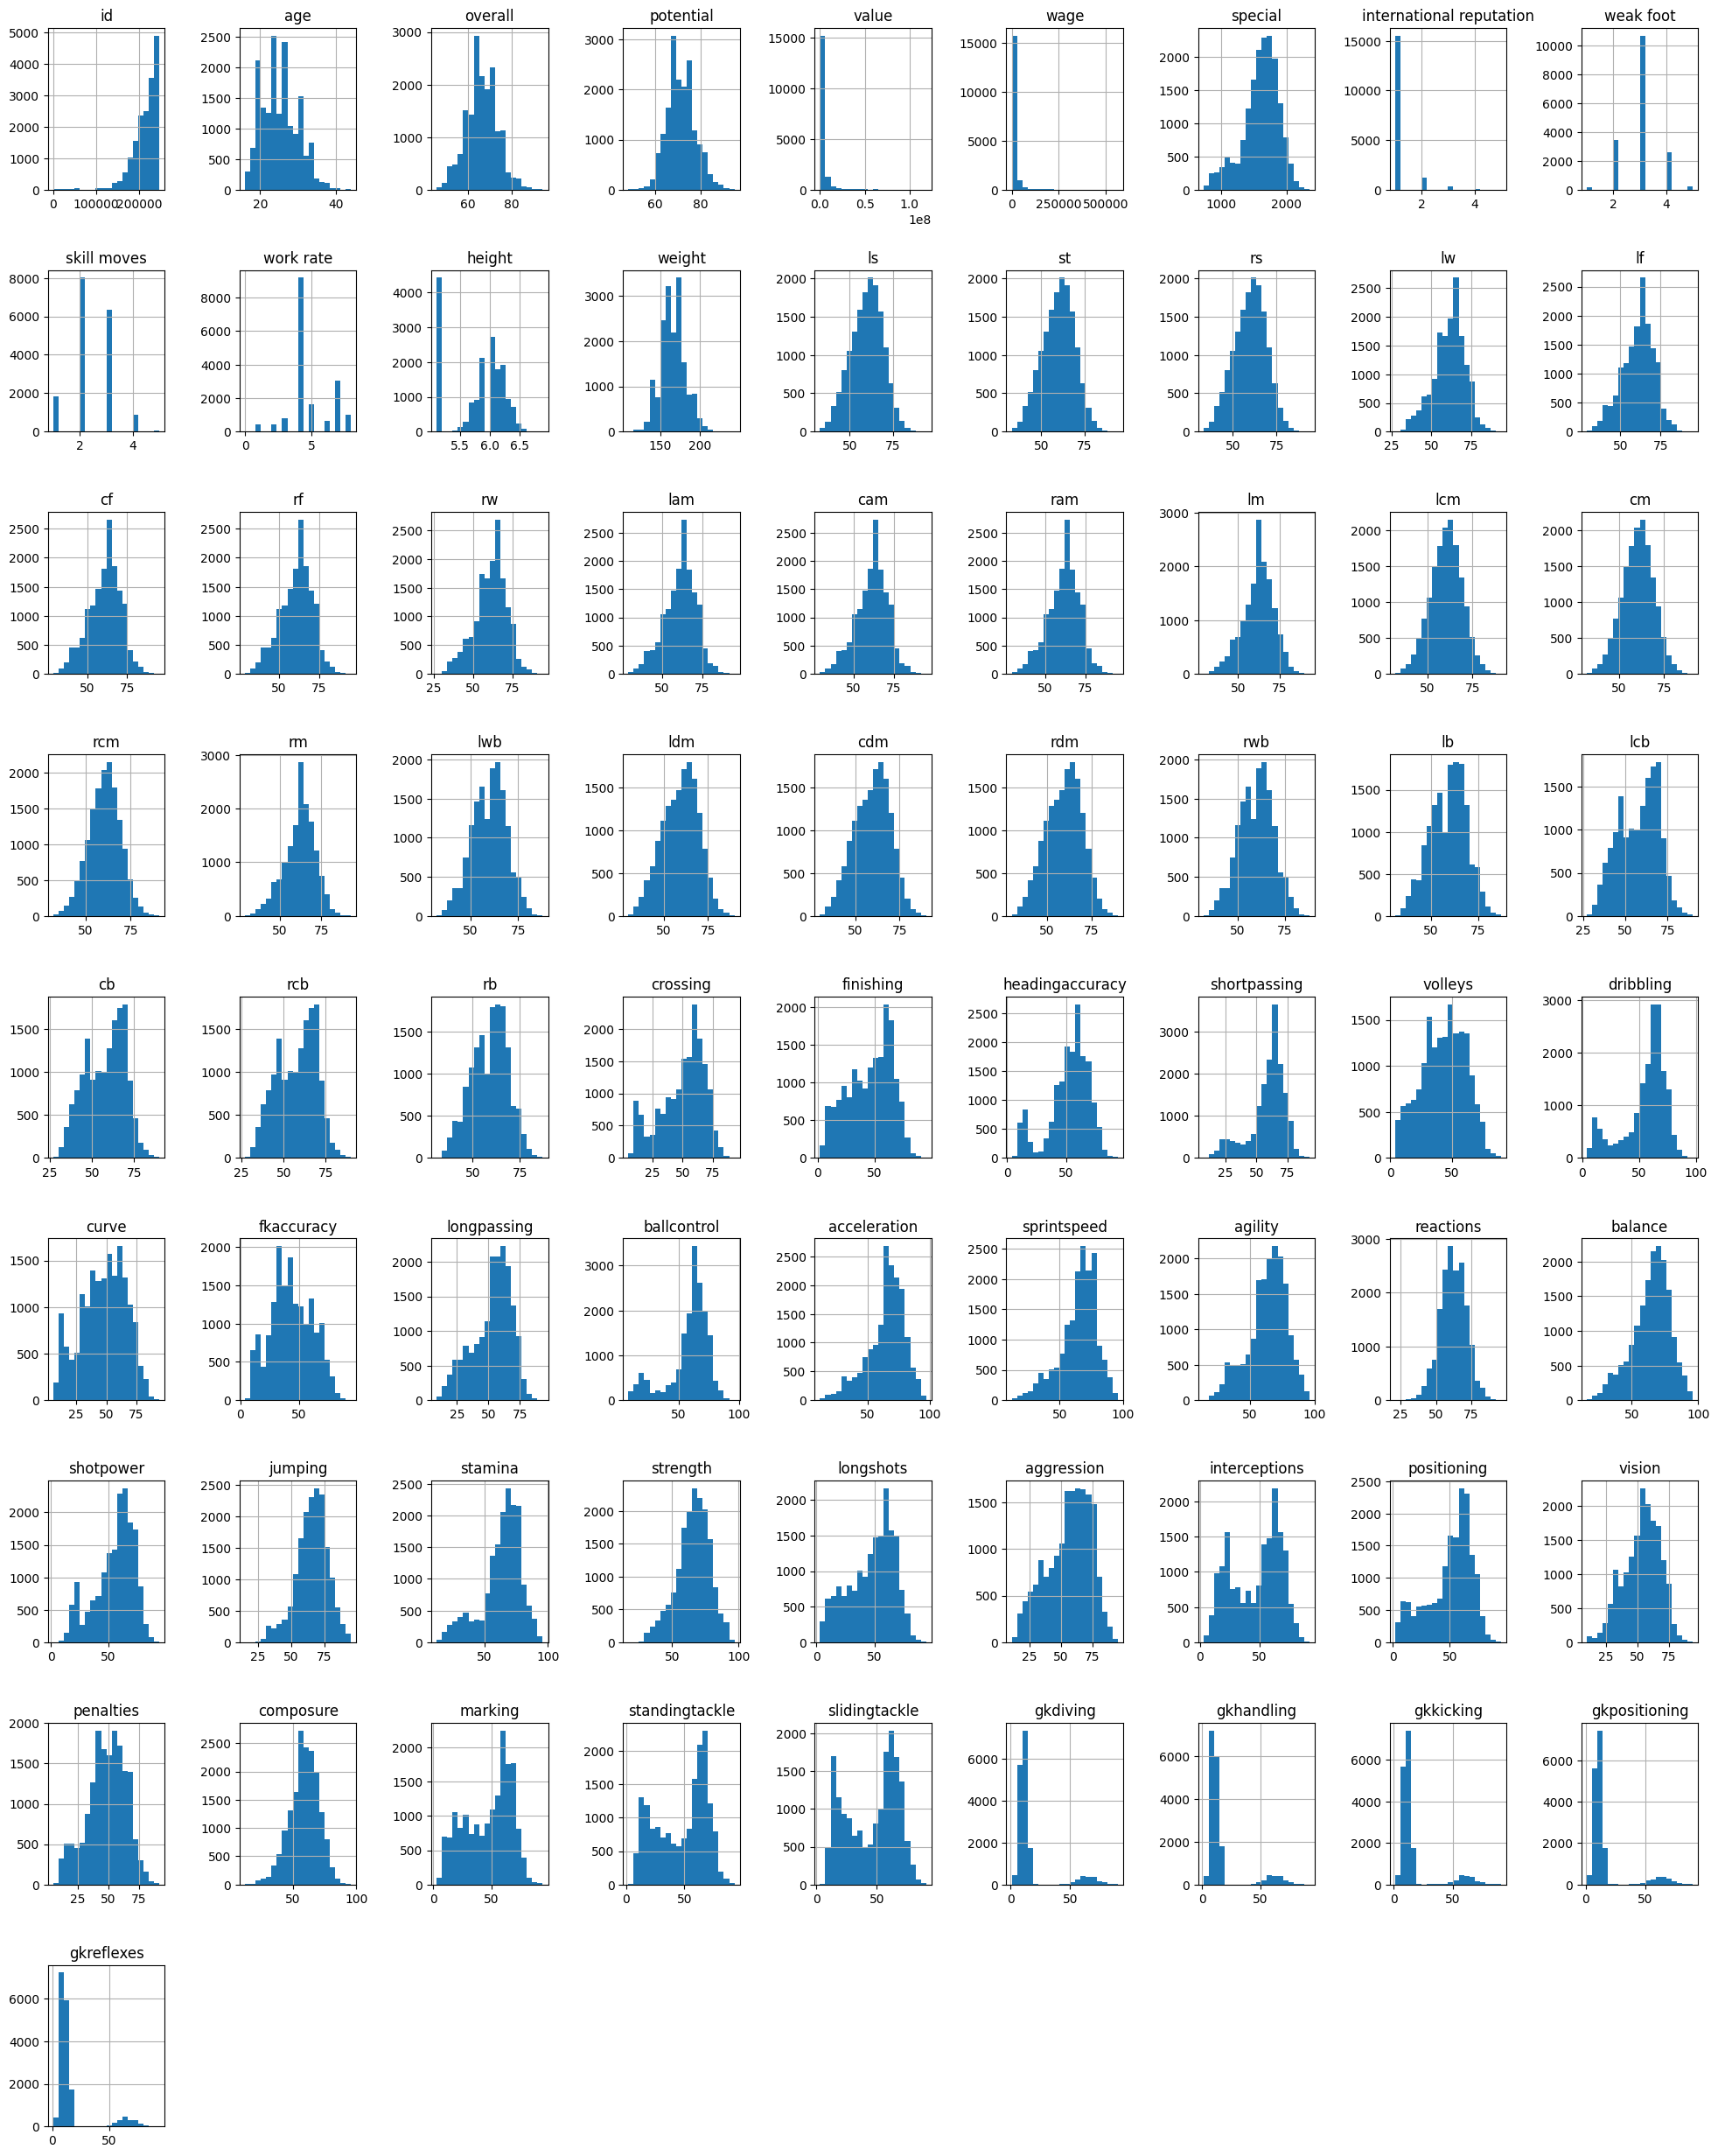

In [ ]:

df.hist(figsize=(20, 25), bins=20)
plt.tight_layout(pad=2.0)
plt.rc('axes', titlesize=10) 
plt.show()

In [ ]:
df[df['position']=='GK']

,id,age,overall,potential,value,wage,special,international reputation,weak foot,skill moves,work rate,height,weight,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,crossing,finishing,headingaccuracy,shortpassing,volleys,dribbling,curve,fkaccuracy,longpassing,ballcontrol,acceleration,sprintspeed,agility,reactions,balance,shotpower,jumping,stamina,strength,longshots,aggression,interceptions,positioning,vision,penalties,composure,marking,standingtackle,slidingtackle,gkdiving,gkhandling,gkkicking,gkpositioning,gkreflexes,preferred foot,body type,position
15298,193080,27,91,93,72000000,260000,1471,4,3,1,4,6.40,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,13,21,50,13,18,21,19,51,42,57,58,60,90,43,31,67,43,64,12,38,30,12,68,40,68,15,21,13,90,85,87,88,94,Right,Lean,GK
15299,200389,25,90,93,68000000,94000,1331,3,3,1,4,6.20,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,11,15,29,13,12,13,14,26,16,43,60,67,86,49,22,76,41,78,12,34,19,11,70,11,70,27,12,18,86,92,78,88,89,Right,Normal,GK
15300,192448,26,89,92,58000000,240000,1328,3,4,1,4,6.20,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,14,11,36,14,17,18,12,42,18,38,50,37,85,43,22,79,35,79,10,43,22,11,69,25,69,25,13,10,87,85,88,85,90,Right,Normal,GK
15301,192119,26,89,90,53500000,240000,1311,4,2,1,4,6.60,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,14,13,33,12,13,19,20,35,23,46,52,61,84,45,36,68,38,70,17,23,15,13,44,27,66,20,18,16,85,91,72,86,88,Left,Lean,GK
15302,167495,32,89,89,38000000,130000,1473,5,4,1,4,6.40,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,13,25,55,11,30,14,11,59,48,54,60,51,84,35,25,77,43,80,16,29,30,12,70,47,70,17,10,11,90,86,91,87,87,Right,Normal,GK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17135,243158,18,48,65,50000,1000,738,1,2,1,4,6.00,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,7,11,22,6,8,10,8,20,12,24,28,33,40,29,15,48,20,38,6,20,10,7,18,12,28,16,11,10,47,46,50,45,51,Right,Lean,GK
17136,221669,22,48,58,40000,1000,987,1,2,1,4,6.10,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,15,15,26,14,13,12,19,19,25,40,42,45,47,52,25,55,33,58,20,20,29,13,20,29,28,12,15,16,45,49,50,50,45,Right,Lean,GK
17137,53748,44,48,48,0,1000,774,1,2,1,4,6.20,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,12,12,18,11,11,12,13,13,16,15,17,31,48,31,23,45,22,44,12,24,15,10,11,22,56,15,15,13,45,48,44,49,46,Right,Normal,GK
17138,245862,18,47,65,50000,1000,731,1,3,1,4,6.30,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,6,10,25,6,12,13,10,20,17,20,14,39,37,22,22,33,15,59,5,17,5,3,28,16,23,6,10,11,52,52,52,40,44,Right,Normal,GK


In [ ]:
df[df['position']!='GK']

,id,age,overall,potential,value,wage,special,international reputation,weak foot,skill moves,work rate,height,weight,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,crossing,finishing,headingaccuracy,shortpassing,volleys,dribbling,curve,fkaccuracy,longpassing,ballcontrol,acceleration,sprintspeed,agility,reactions,balance,shotpower,jumping,stamina,strength,longshots,aggression,interceptions,positioning,vision,penalties,composure,marking,standingtackle,slidingtackle,gkdiving,gkhandling,gkkicking,gkpositioning,gkreflexes,preferred foot,body type,position
0,158023,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26,6,11,15,14,8,Left,Lean,ST
1,20801,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23,7,11,15,14,11,Right,Normal,ST
2,190871,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33,9,9,15,15,11,Right,Lean,AM
3,192985,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51,15,13,5,10,13,Right,Normal,MF
4,183277,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22,11,12,6,8,8,Right,Normal,ST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15293,243413,18,47,68,60000,1000,1098,1,3,2,4,6.10,168,34.0,34.0,34.0,31.0,32.0,32.0,32.0,31.0,30.0,30.0,30.0,32.0,32.0,32.0,32.0,32.0,41.0,40.0,40.0,40.0,41.0,44.0,48.0,48.0,48.0,44.0,22,23,45,25,27,21,21,27,27,32,52,52,39,43,48,39,74,39,52,16,44,45,20,31,38,43,44,47,53,9,10,9,11,13,Left,Lean,DF
15294,243165,19,47,63,60000,1000,1098,1,2,2,4,6.30,170,47.0,47.0,47.0,41.0,44.0,44.0,44.0,41.0,42.0,42.0,42.0,40.0,37.0,37.0,37.0,40.0,32.0,33.0,33.0,33.0,32.0,31.0,34.0,34.0,34.0,31.0,23,52,52,43,36,39,32,20,25,40,41,39,38,40,52,41,47,43,67,42,47,16,46,33,43,42,22,15,19,10,9,9,5,12,Right,Normal,ST
15295,241638,16,47,67,60000,1000,1189,1,3,2,4,5.80,148,47.0,47.0,47.0,47.0,48.0,48.0,48.0,47.0,46.0,46.0,46.0,46.0,40.0,40.0,40.0,46.0,36.0,32.0,32.0,32.0,36.0,35.0,30.0,30.0,30.0,35.0,25,40,46,38,38,45,38,27,28,44,70,69,50,47,58,45,60,55,32,45,32,15,48,43,55,41,32,13,11,6,5,10,6,13,Right,Normal,ST
15296,246268,17,47,66,60000,1000,1228,1,3,2,4,5.10,154,49.0,49.0,49.0,49.0,48.0,48.0,48.0,49.0,47.0,47.0,47.0,48.0,41.0,41.0,41.0,48.0,38.0,34.0,34.0,34.0,38.0,37.0,33.0,33.0,33.0,37.0,44,50,39,42,40,51,34,32,32,52,61,60,52,21,71,64,42,40,48,34,33,22,44,47,50,46,20,25,27,14,6,14,8,9,Right,Lean,AM


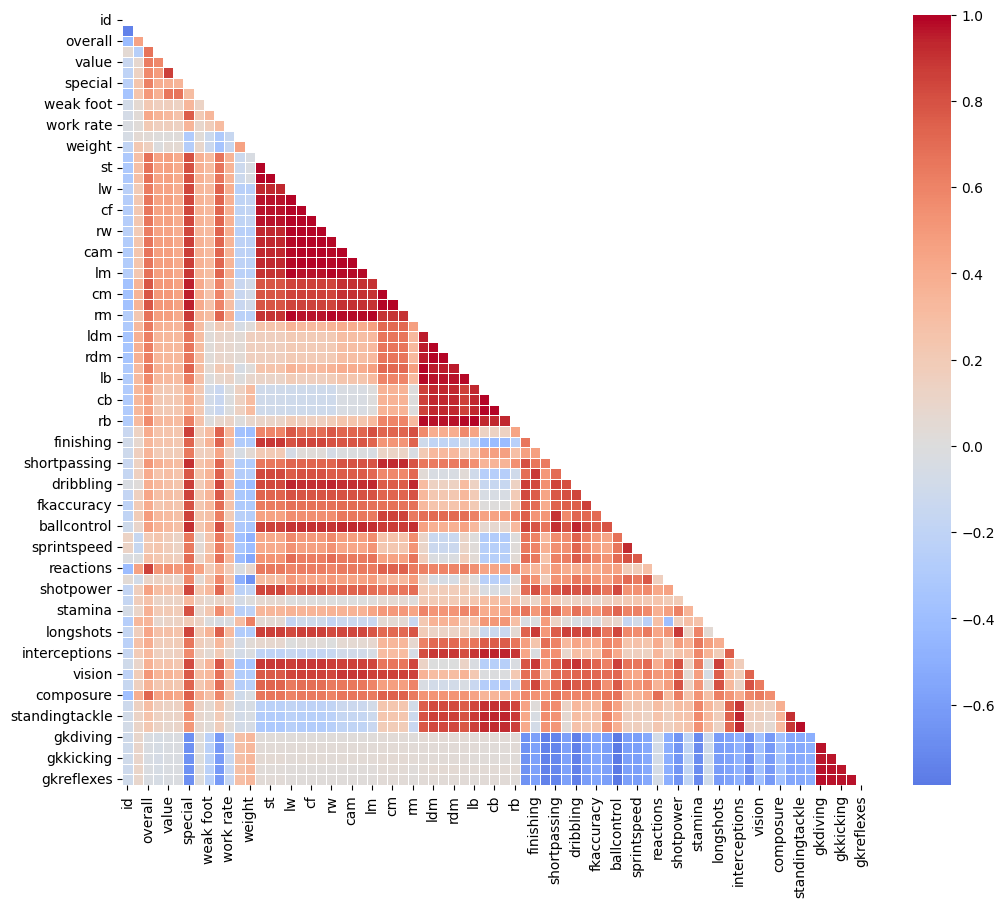

In [ ]:

corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.show()

In [ ]:
df['body type'].value_counts()

body type
Normal    9990
Lean      6080
Stocky    1070
Name: count, dtype: int64

### Visualizacion en  2 dimensiones del conjunto  de alta dimensionalidad (jugadores)

In [ ]:
df_jugadores = (df[df['position']!='GK']).reset_index(drop=True)
df_jugadores.set_index(um,inplace=True,drop=True)
df_jugadores.drop(columns=["preferred foot", "body type", 'gkdiving',
    'gkhandling',
    'gkkicking',
    'gkpositioning',
    'gkreflexes'
],inplace=True)
df_jugadores

,,age,overall,potential,value,wage,special,international reputation,weak foot,skill moves,work rate,height,weight,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,crossing,finishing,headingaccuracy,shortpassing,volleys,dribbling,curve,fkaccuracy,longpassing,ballcontrol,acceleration,sprintspeed,agility,reactions,balance,shotpower,jumping,stamina,strength,longshots,aggression,interceptions,positioning,vision,penalties,composure,marking,standingtackle,slidingtackle
id,position,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
158023,ST,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26
20801,ST,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23
190871,AM,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33
192985,MF,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51
183277,ST,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243413,DF,18,47,68,60000,1000,1098,1,3,2,4,6.10,168,34.0,34.0,34.0,31.0,32.0,32.0,32.0,31.0,30.0,30.0,30.0,32.0,32.0,32.0,32.0,32.0,41.0,40.0,40.0,40.0,41.0,44.0,48.0,48.0,48.0,44.0,22,23,45,25,27,21,21,27,27,32,52,52,39,43,48,39,74,39,52,16,44,45,20,31,38,43,44,47,53
243165,ST,19,47,63,60000,1000,1098,1,2,2,4,6.30,170,47.0,47.0,47.0,41.0,44.0,44.0,44.0,41.0,42.0,42.0,42.0,40.0,37.0,37.0,37.0,40.0,32.0,33.0,33.0,33.0,32.0,31.0,34.0,34.0,34.0,31.0,23,52,52,43,36,39,32,20,25,40,41,39,38,40,52,41,47,43,67,42,47,16,46,33,43,42,22,15,19
241638,ST,16,47,67,60000,1000,1189,1,3,2,4,5.80,148,47.0,47.0,47.0,47.0,48.0,48.0,48.0,47.0,46.0,46.0,46.0,46.0,40.0,40.0,40.0,46.0,36.0,32.0,32.0,32.0,36.0,35.0,30.0,30.0,30.0,35.0,25,40,46,38,38,45,38,27,28,44,70,69,50,47,58,45,60,55,32,45,32,15,48,43,55,41,32,13,11


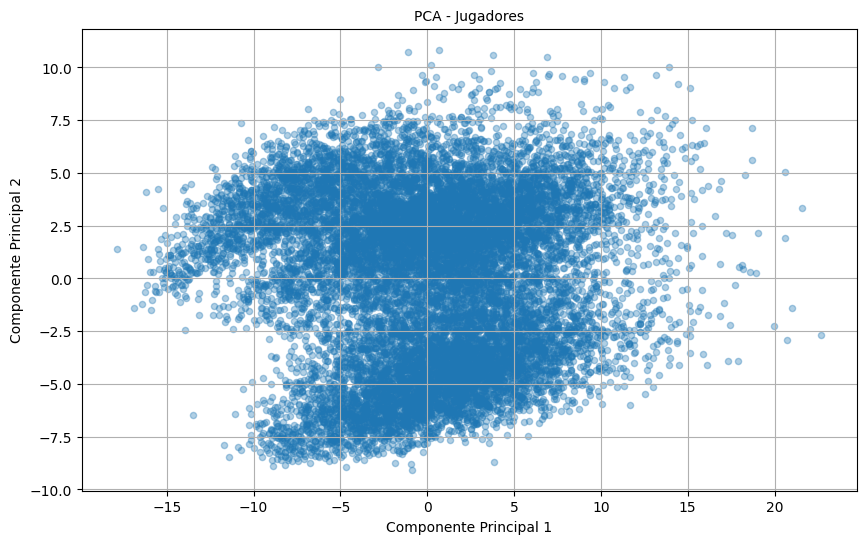

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_jugadores)
# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
# =========================
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=20,          
    alpha=0.35     
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Jugadores')

plt.grid(True)
plt.show()

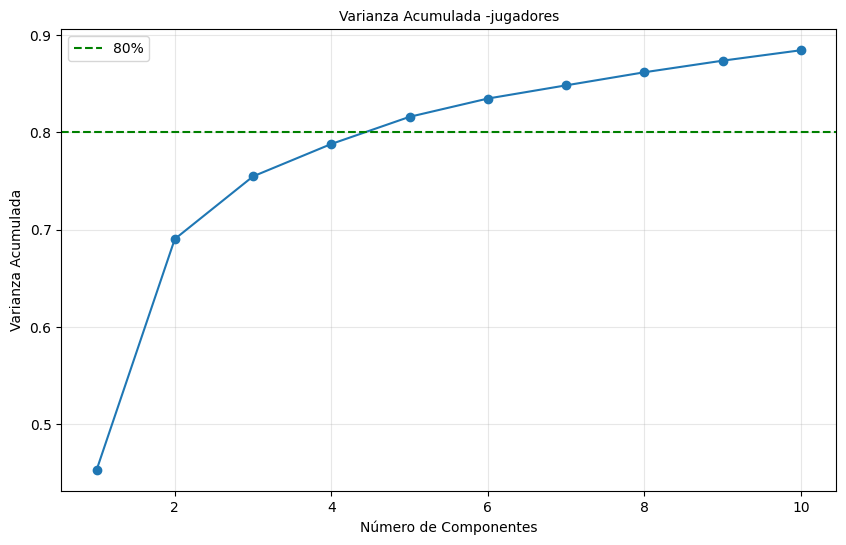

In [ ]:


# Varianza acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(varianza_acumulada)+1),
    varianza_acumulada,
    marker='o'
)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada -jugadores')

plt.axhline(y=0.8, color='g', linestyle='--', label='80%')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
del X_scaled, X_pca, pca,varianza_acumulada
gc.collect()



270928

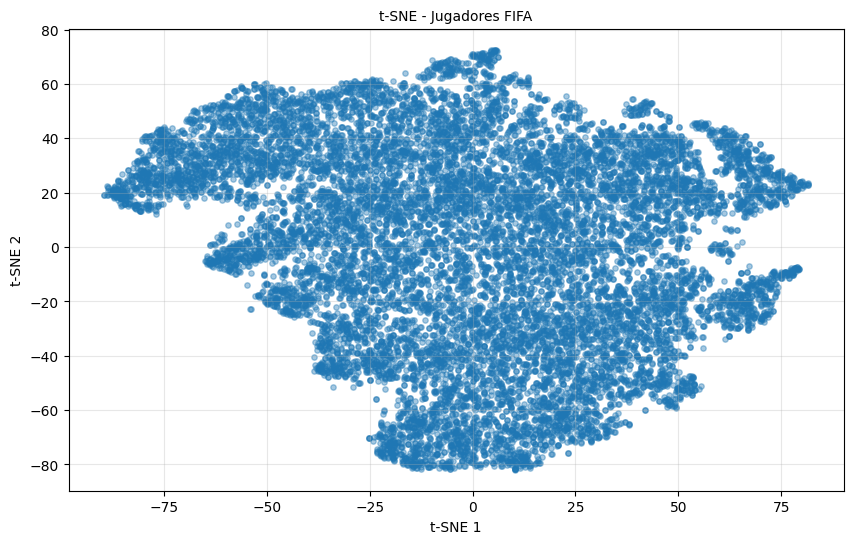

In [ ]:


# 1. Escalar datos
X_scaled = StandardScaler().fit_transform(df_jugadores)

# 2. t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# 3. Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=15, alpha=0.4)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE - Jugadores FIFA')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
del X_scaled, X_tsne, tsne
gc.collect()

3651

### Agrupamiento

    k        inercia  silhouette  calinski_harabasz  davies_bouldin
0   2  730202.709411    0.239684        6174.594139        1.507910
1   3  589098.438484    0.237028        5658.304750        1.373599
2   4  516120.799414    0.206503        5026.136117        1.447409
3   5  465807.646874    0.199889        4589.454411        1.419691
4   6  436641.171507    0.175171        4120.853502        1.555748
5   7  415805.296311    0.169159        3733.588935        1.576917
6   8  398137.073313    0.157337        3438.951604        1.656833
7   9  380843.760054    0.151370        3232.291677        1.660124
8  10  367521.909482    0.151384        3038.673553        1.663511


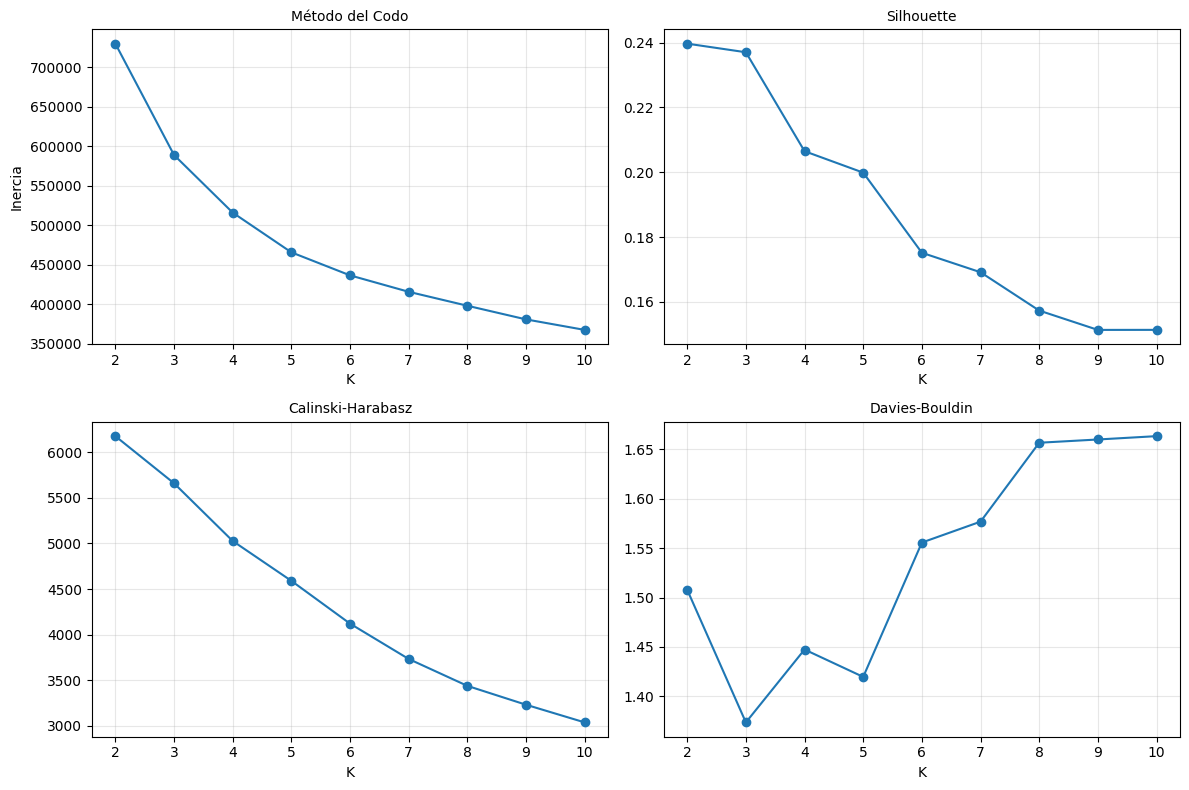

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

ks = range(2, 11)
resultados = []

X_reducido = StandardScaler().fit_transform(df_jugadores)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reducido)

    resultados.append([
        k,
        km.inertia_,
        silhouette_score(X_reducido, labels),
        calinski_harabasz_score(X_reducido, labels),
        davies_bouldin_score(X_reducido, labels)
    ])

df_metricas = pd.DataFrame(resultados, columns=[
    'k', 'inercia', 'silhouette', 'calinski_harabasz', 'davies_bouldin'
])

print(df_metricas)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(df_metricas['k'], df_metricas['inercia'], marker='o')
plt.title('Método del Codo')
plt.xlabel('K'); plt.ylabel('Inercia'); plt.grid(True, alpha=0.3)

plt.subplot(2,2,2)
plt.plot(df_metricas['k'], df_metricas['silhouette'], marker='o')
plt.title('Silhouette')
plt.xlabel('K'); plt.grid(True, alpha=0.3)

plt.subplot(2,2,3)
plt.plot(df_metricas['k'], df_metricas['calinski_harabasz'], marker='o')
plt.title('Calinski-Harabasz')
plt.xlabel('K'); plt.grid(True, alpha=0.3)

plt.subplot(2,2,4)
plt.plot(df_metricas['k'], df_metricas['davies_bouldin'], marker='o')
plt.title('Davies-Bouldin')
plt.xlabel('K'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
del ks,resultados,X_reducido,km,labels,df_metricas
gc.collect()

13306

In [ ]:

X_scaled = StandardScaler().fit_transform(df_jugadores)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_jugadores['cluster'] = clusters

df_jugadores.head()

,,age,overall,potential,value,wage,special,international reputation,weak foot,skill moves,work rate,height,weight,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,crossing,finishing,headingaccuracy,shortpassing,volleys,dribbling,curve,fkaccuracy,longpassing,ballcontrol,acceleration,sprintspeed,agility,reactions,balance,shotpower,jumping,stamina,strength,longshots,aggression,interceptions,positioning,vision,penalties,composure,marking,standingtackle,slidingtackle,cluster
id,position,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
158023,ST,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26,0
20801,ST,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23,0
190871,AM,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33,0
192985,MF,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51,0
183277,ST,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22,0


In [ ]:
df_jugadores['cluster'].value_counts(normalize=True)

cluster
0    0.381030
1    0.314093
2    0.304876
Name: proportion, dtype: float64

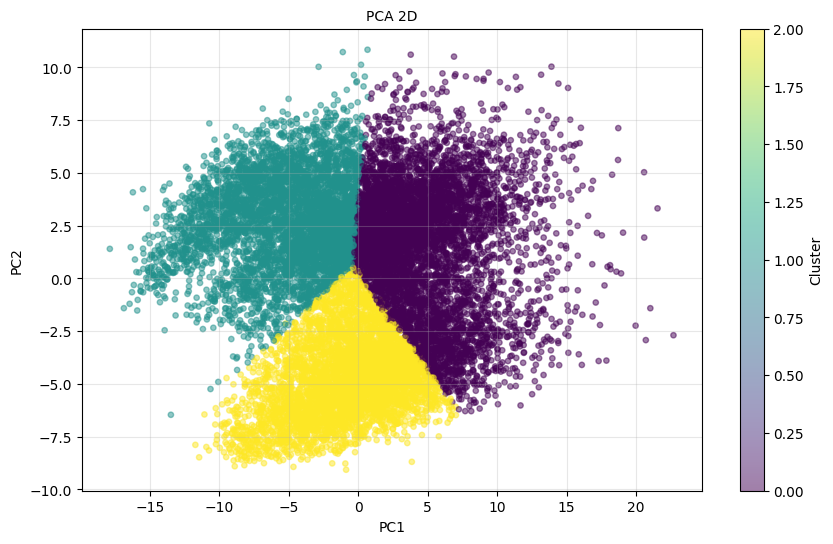

In [ ]:

X_scaled = StandardScaler().fit_transform(df_jugadores.drop(columns=['cluster']))

X_pca = PCA(n_components=2).fit_transform(X_scaled)


plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_jugadores['cluster'],
    cmap='viridis',
    s=15,
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
del X_scaled,X_pca
gc.collect()

12201

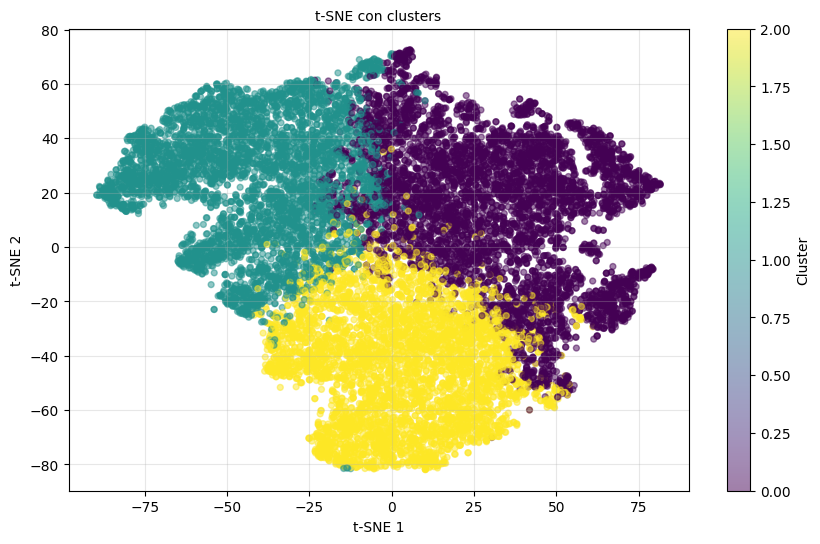

In [ ]:



X_scaled = StandardScaler().fit_transform(df_jugadores.drop(columns=['cluster']))

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df_jugadores['cluster'],
    cmap='viridis',
    s=18,
    alpha=0.5
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE con clusters')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df_jugadores[['cluster',
    'overall', 'potential',
    
    'finishing', 'positioning', 'shotpower', 'longshots',
    
    'vision', 'shortpassing', 'longpassing',
    
    'dribbling', 'ballcontrol',
    
    'marking', 'standingtackle', 'interceptions',
    
    'sprintspeed', 'acceleration', 'stamina', 'strength',
    
    'aggression', 'composure'
]].groupby('cluster').mean()


,overall,potential,finishing,positioning,shotpower,longshots,vision,shortpassing,longpassing,dribbling,ballcontrol,marking,standingtackle,interceptions,sprintspeed,acceleration,stamina,strength,aggression,composure
cluster,,,,,,,,,,,,,,,,,,,,
0,71.614685,74.367301,56.791388,63.620861,68.028650,62.149425,65.610225,70.718991,65.970149,68.953165,70.985075,58.700806,60.439355,59.973580,70.437296,70.866015,74.002402,67.360268,66.638875,67.824841
1,63.379813,69.365869,31.734860,39.399168,47.630177,35.292196,43.465140,56.854110,51.095317,48.142352,54.217690,60.791883,63.734651,60.608325,61.685328,60.866805,65.044329,69.866181,63.485536,54.641831
2,63.613208,70.347341,60.201758,60.473413,62.182247,55.610420,56.087479,59.250429,49.799743,63.718268,63.439322,32.739923,29.696398,28.669597,71.660806,71.770369,61.884434,60.235849,47.352058,57.489923


In [ ]:
df.

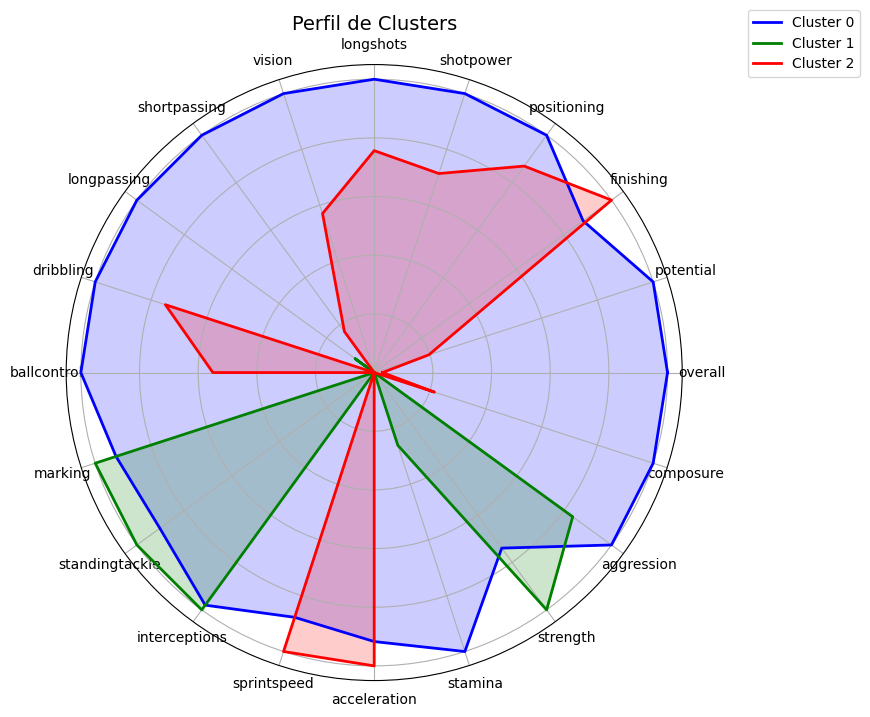

In [ ]:


# Variables para el radar (6 = hexágono)
cols_radar = [
    'overall', 'potential',
    
    'finishing', 'positioning', 'shotpower', 'longshots',
    
    'vision', 'shortpassing', 'longpassing',
    
    'dribbling', 'ballcontrol',
    
    'marking', 'standingtackle', 'interceptions',
    
    'sprintspeed', 'acceleration', 'stamina', 'strength',
    
    'aggression', 'composure'
]

# Perfil por cluster
perfil = df_jugadores.groupby('cluster')[cols_radar].mean()

# Normalizar (IMPORTANTE)
scaler = MinMaxScaler()
perfil_norm = scaler.fit_transform(perfil)

# Convertir a lista
perfil_norm = perfil_norm.tolist()

# Ángulos
labels = cols_radar
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar figura

# Figura
plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

# Colores
colors = ['blue', 'green', 'red']

# Graficar cada cluster
for i, valores in enumerate(perfil_norm):
    valores += valores[:1]  # cerrar figura
    ax.plot(angles, valores, linewidth=2, label=f'Cluster {i}', color=colors[i])
    ax.fill(angles, valores, alpha=0.2, color=colors[i])

# Etiquetas
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Quitar escala radial
ax.set_yticklabels([])

# Título
plt.title('Perfil de Clusters', size=14)

# Leyenda
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

# 📊 Perfil de Clusters - Jugadores FIFA

A partir del análisis de clustering se identificaron **3 grupos principales de jugadores**, los cuales representan perfiles futbolísticos claros:

---

## 🔵 Cluster 0 → 🎯 Jugadores completos / creativos

### 📌 Características:
- Alto en **passing, vision y dribbling**
- Buen nivel en **finishing**
- Defensa media
- Buen físico y compostura

### ⚽ Tipo de jugador:
- Mediocampistas ofensivos (CAM)
- Mediocampistas centrales (CM)
- Box-to-box

### 🧠 Interpretación:
Jugadores equilibrados que participan tanto en ataque como en creación de juego.

---

## 🟢 Cluster 1 → 🛡️ Defensivos

### 📌 Características:
- Alto en **marking, tackles e interceptions**
- Alta **fuerza y agresividad**
- Bajo en ataque y técnica

### ⚽ Tipo de jugador:
- Defensas centrales (CB)
- Mediocampistas defensivos (CDM)
- Laterales defensivos

### 🧠 Interpretación:
Jugadores especializados en recuperación de balón y defensa.

---

## 🔴 Cluster 2 → ⚡ Atacantes

### 📌 Características:
- Alto en **finishing**
- Muy alta **velocidad y aceleración**
- Buen dribbling
- Defensa muy baja

### ⚽ Tipo de jugador:
- Delanteros (ST)
- Extremos (LW / RW)

### 🧠 Interpretación:
Jugadores enfocados en ataque, velocidad y generación de gol.

---

## 🎯 Conclusión

El modelo logró identificar correctamente tres perfiles clave del fútbol:

- 🎯 Creatividad y balance
- 🛡️ Defensa
- ⚡ Ataque y velocidad

Estos clusters reflejan la estructura real de roles dentro del juego.

### Visualizacion en  2 dimensiones del conjunto  de alta dimensionalidad (porteros)